# 6주차_딥러닝과_텐서플로

- Preview
- 딥러닝의 등장
- 텐서플로 개념 익히기
- 텐서플로 프로그래밍 기초
- 텐서플로로 다층 퍼셉트론 프로그래밍
- 깊은 다층 퍼셉트론
- 딥러닝의 학습 전략
- 딥러닝이 사용하는 손실 함수
- 딥러닝이 사용하는 옵티마이저
- 좋은 프로그래밍 스킬
- 교차 검증을 이용한 하이퍼 매개변수 최적화

---

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 TensorFlow의 버전을 출력하고,
# 0과 1 사이에서 무작위로 생성된 2행 3열 텐서를 생성 및 출력하며,
# 해당 텐서 객체의 자료형을 확인하는 실습 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: TensorFlow 모듈 임포트 및 버전 출력
# 2단계: 무작위 텐서 생성 및 출력
# 3단계: 텐서 객체의 타입 확인
# ------------------------------------------------------------

import tensorflow as tf  # 딥러닝 프레임워크 TensorFlow 라이브러리를 tf라는 이름으로 임포트함

print(tf.__version__)  # 현재 설치된 TensorFlow의 버전 정보를 문자열 형태로 출력함

a = tf.random.uniform([2, 3], 0, 1)  
# shape이 (2행, 3열)인 텐서를 무작위로 생성함
# 값의 범위는 [0, 1)이며, 균등 분포를 따름
# 반환되는 객체는 TensorFlow의 Tensor 클래스에 해당함

print(a)  # 생성된 무작위 텐서의 실제 값을 출력함

print(type(a))  
# 변수 a가 어떤 타입(Tensor 클래스 또는 다른 객체)인지 출력함
# 보통 출력 결과는 <class 'tensorflow.python.framework.ops.EagerTensor'> 
# 또는 <class 'tensorflow.Tensor'>로 나타남


2.19.0
tf.Tensor(
[[0.27468956 0.39546037 0.1225121 ]
 [0.7470132  0.6301923  0.2090981 ]], shape=(2, 3), dtype=float32)
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 TensorFlow와 NumPy 각각을 이용하여 2행 3열의 무작위 배열을 생성하고,  
# 서로의 자료형 차이를 비교한 후, 텐서(Tensor)와 배열(ndarray) 간의 **브로드캐스팅 기반 연산 호환성**을 실험하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: TensorFlow 텐서 생성
# 2단계: NumPy 배열 생성
# 3단계: 각 객체 출력 및 자료형 확인
# 4단계: 두 객체 간의 덧셈 연산 수행 및 결과 출력
# ------------------------------------------------------------

import tensorflow as tf  # 딥러닝용 텐서 연산 라이브러리 TensorFlow를 불러옴
import numpy as np       # 과학 계산 및 배열 처리를 위한 NumPy를 불러옴

# ------------------------------------------------------------
# [1단계] TensorFlow 무작위 텐서 생성
# ------------------------------------------------------------

t = tf.random.uniform([2, 3], 0, 1)  
# shape이 (2,3)인 텐서를 생성함
# 각 원소는 0 이상 1 미만 범위의 균등 분포에서 무작위로 생성됨
# 생성된 객체는 TensorFlow의 EagerTensor 타입임

# ------------------------------------------------------------
# [2단계] NumPy 무작위 배열 생성
# ------------------------------------------------------------

n = np.random.uniform(0, 1, [2, 3])  
# shape이 (2,3)인 NumPy 배열(ndarray)을 생성함
# 각 원소는 0 이상 1 미만 범위의 균등 분포에서 무작위로 생성됨

# ------------------------------------------------------------
# [3단계] 각 객체 출력 및 자료형 확인
# ------------------------------------------------------------

print("tensorflow로 생성한 텐서:\n", t, "\n")  
# TensorFlow로 생성한 무작위 텐서의 값과 메타정보 출력

print(type(t))  
# 객체 t의 자료형을 확인함 → 출력: <class 'tensorflow.python.framework.ops.EagerTensor'>

print("numpy로 생성한 ndarray:\n", n, "\n")  
# NumPy로 생성한 무작위 배열의 값을 출력함

print(type(n))  
# 객체 n의 자료형을 확인함 → 출력: <class 'numpy.ndarray'>

# ------------------------------------------------------------
# [4단계] Tensor와 ndarray 간 덧셈 연산 및 출력
# ------------------------------------------------------------

res = t + n  
# TensorFlow 텐서와 NumPy 배열 간의 원소별 덧셈 연산을 수행함
# TensorFlow는 내부적으로 NumPy 배열을 Tensor로 자동 변환하여 연산을 처리함 (브로드캐스팅 지원)

print("덧셈 결과:\n", res)  
# 연산 결과인 res의 값(2×3 행렬)을 출력함

print(type(res))  
# 덧셈 결과 res의 자료형을 확인함 → TensorFlow Tensor 객체로 반환됨


# TensorFlow와 NumPy 간의 연산이 가능한 이유
    # TensorFlow가 NumPy 객체를 자동으로 Tensor로 변환함
    # NumPy 연산과 호환되도록 설계된 TensorFlow 연산 시스템

tensorflow로 생성한 텐서:
 tf.Tensor(
[[0.9289051  0.05414236 0.17922759]
 [0.49006116 0.7837758  0.91267323]], shape=(2, 3), dtype=float32) 

<class 'tensorflow.python.framework.ops.EagerTensor'>
numpy로 생성한 ndarray:
 [[0.84476668 0.35732214 0.88504317]
 [0.17132044 0.68406422 0.51400863]] 

<class 'numpy.ndarray'>
덧셈 결과:
 tf.Tensor(
[[1.7736719  0.41146448 1.0642707 ]
 [0.6613816  1.46784    1.4266819 ]], shape=(2, 3), dtype=float32)
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 TensorFlow에서 제공하는 대표적인 내장 데이터셋(MNIST, CIFAR-10, Boston Housing, Reuters)을 불러오고,  
# 각각의 학습/테스트 데이터의 구조(shape)를 출력함으로써 입력 및 라벨의 형태를 파악하는 예제임.  
# 다중 분류 문제에서는 라벨을 원-핫 인코딩(one-hot encoding)으로 변환하여 출력 형식을 비교함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: MNIST 이미지 데이터셋 로딩 및 라벨 원-핫 인코딩
# 2단계: CIFAR-10 이미지 데이터셋 로딩 및 라벨 원-핫 인코딩
# 3단계: Boston Housing 회귀 데이터셋 로딩
# 4단계: Reuters 뉴스 기사 분류 데이터셋 로딩
# ------------------------------------------------------------

import tensorflow as tf                              # TensorFlow 라이브러리 임포트
import tensorflow.keras.datasets as ds               # keras.datasets 모듈을 짧은 이름으로 임포트

# ------------------------------------------------------------
# [1단계] MNIST 데이터셋 로딩 및 라벨 변환
# ------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = ds.mnist.load_data()  
# 손글씨 숫자(0~9)를 분류하기 위한 MNIST 데이터셋을 로딩함
# x_train: (60000, 28, 28), y_train: (60000,), 정수형 라벨

yy_train = tf.one_hot(y_train, 10, dtype=tf.int8)  
# y_train의 정수형 라벨을 10차원 원-핫 인코딩 벡터로 변환함
# yy_train: (60000, 10)

print("MNIST: ", x_train.shape, y_train.shape, yy_train.shape)  
# 입력 이미지, 정수형 라벨, 원-핫 벡터의 shape 출력

# ------------------------------------------------------------
# [2단계] CIFAR-10 데이터셋 로딩 및 라벨 변환
# ------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = ds.cifar10.load_data()  
# 10개 클래스의 컬러 이미지(32x32 RGB)를 분류하는 CIFAR-10 데이터셋을 로딩함
# x_train: (50000, 32, 32, 3), y_train: (50000, 1)

yy_train = tf.one_hot(y_train, 10, dtype=tf.int8)  
# CIFAR-10 라벨을 원-핫 인코딩으로 변환함
# yy_train: (50000, 1, 10) → 2차원 라벨로부터 3차원 텐서 생성됨

print("CIFAR-10: ", x_train.shape, y_train.shape, yy_train.shape)  
# 입력 이미지와 라벨, 원-핫 라벨의 shape 출력

# ------------------------------------------------------------
# [3단계] Boston Housing 데이터셋 로딩
# ------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = ds.boston_housing.load_data()  
# 집값 예측을 위한 회귀용 데이터셋 로딩 (13개 특성 사용)
# x_train: (404, 13), y_train: (404,)

print("Boston Housing: ", x_train.shape, y_train.shape)  
# 입력 특성과 실제 가격값 벡터의 shape 출력

# ------------------------------------------------------------
# [4단계] Reuters 뉴스 텍스트 데이터셋 로딩
# ------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = ds.reuters.load_data()  
# 다중 클래스 뉴스 기사 분류용 텍스트 데이터셋 로딩
# 각 뉴스는 단어 인덱스로 구성된 시퀀스 (길이 가변), 라벨은 정수형 (46개 클래스)

print("Reuters: ", x_train.shape, y_train.shape)  
# 시퀀스 입력과 라벨 벡터의 shape 출력 (ex: (8982,), (8982,))


MNIST:  (60000, 28, 28) (60000,) (60000, 10)
CIFAR-10:  (50000, 32, 32, 3) (50000, 1) (50000, 1, 10)
Boston Housing:  (404, 13) (404,)
Reuters:  (8982,) (8982,)


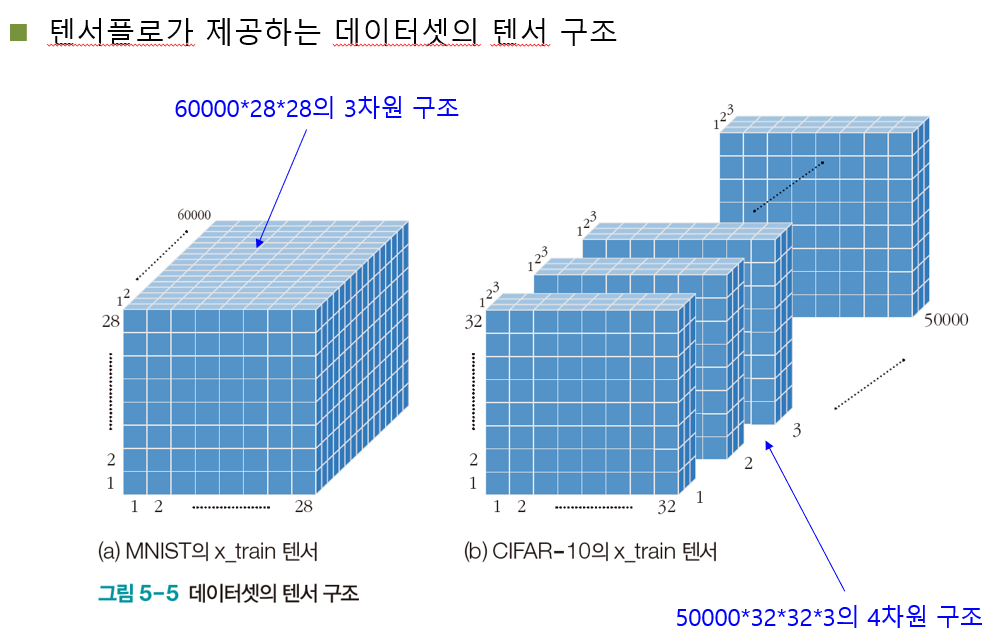

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 TensorFlow를 활용하여 퍼셉트론(Perceptron) 구조를 구현하고,  
# 논리 연산 중 OR 문제를 퍼셉트론으로 분류하는 실험을 수행함.  
# 입력값과 가중치, 편향을 수동으로 설정한 후,  
# 선형 결합 + 부호 함수(sign)를 이용한 퍼셉트론 예측을 통해  
# 출력이 정답 라벨과 일치하는지를 검증함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: OR 논리 연산 데이터셋 정의 (입력/정답)
# 2단계: 퍼셉트론 가중치 및 편향 초기화
# 3단계: 선형결합 및 활성화 함수(sign) 적용
# 4단계: 예측 결과 및 정답 비교 수행
# ------------------------------------------------------------

import tensorflow as tf  # 텐서 연산 및 자동 미분 기능을 제공하는 TensorFlow 라이브러리 임포트

# ------------------------------------------------------------
# [1단계] 입력 데이터 정의
# ------------------------------------------------------------

x = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]  
# OR 논리 연산에 사용되는 2차원 입력 벡터 집합 정의
# 총 4개의 입력 쌍 (0 OR 0), (0 OR 1), (1 OR 0), (1 OR 1)을 포함함

y = [[-1], [1], [1], [1]]  
# OR 연산의 기대 정답을 정의함
# 논리값 False를 -1, True를 1로 표현
# OR 결과는 (False, True, True, True)에 해당함

# ------------------------------------------------------------
# [2단계] 퍼셉트론 파라미터 초기화
# ------------------------------------------------------------

w = tf.Variable([[1.0], [1.0]])  
# 각 입력에 대응되는 가중치 w₁=1, w₂=1을 담은 2×1 행렬 형태로 초기화함

b = tf.Variable(-0.5)  
# 퍼셉트론의 편향(bias) 값 b = -0.5로 설정함

# ┌────────────────────────────┬───────────────────────────────────────────────────────────┐
# │          질문              │                                 답변                                       │
# ├────────────────────────────┼───────────────────────────────────────────────────────────┤
# │ 퍼셉트론의 가중치와             │ 원하는 분류를 만족하는 부등식 조건을 만족해야 합니다.                      │
# │ 편향을 어떻게 알 수 있나요?       │ 작거나 단순한 문제는 수학적으로 직접 풀 수 있습니다.                        │
# ├────────────────────────────┼───────────────────────────────────────────────────────────┤
# │ 공식처럼 딱 정해진 값이        │ 아니요, 여러 조합이 가능합니다. 단, 조건을 만족하는 범위 내여야 합니다.        │
# │ 있나요?                    │                                                             │
# ├────────────────────────────┼───────────────────────────────────────────────────────────┤
# │ 현실 문제는 어떻게              │ 학습 알고리즘(퍼셉트론 학습 규칙, 경사하강법 등)을 통해                     │
# │ 해결하나요?                     │ 데이터 기반으로 가중치(w)와 편향(b)을 찾습니다.                         │
# └────────────────────────────┴────────────────────────────────────────────────────────────┘

# ------------------------------------------------------------
# [3단계] 퍼셉트론 연산: 선형 결합 및 활성화 함수 적용
# ------------------------------------------------------------

s = tf.add(tf.matmul(x, w), b)  
# 선형 결합 계산 수행
# s = x·w + b = [0·1 + 0·1 + (-0.5), ...] 형태로 계산됨
# 결과는 shape (4, 1)의 텐서가 됨

o = tf.sign(s)  
# sign 활성화 함수 적용
# tf.sign()은 양수일 경우 1, 음수일 경우 -1, 0일 경우 0을 반환함
# 퍼셉트론의 출력 역할 수행

# ------------------------------------------------------------
# [4단계] 출력 결과 및 정답 비교
# ------------------------------------------------------------

print(o)  
# 퍼셉트론의 예측 결과 출력 (기대값: [[-1], [1], [1], [1]])

print(y == o)  
# 정답 y와 예측 결과 o를 비교하여 각 샘플이 일치하는지 Boolean 배열로 출력
# 결과: [[True], [True], [True], [True]]


tf.Tensor(
[[-1.]
 [ 1.]
 [ 1.]
 [ 1.]], shape=(4, 1), dtype=float32)
tf.Tensor(
[[ True]
 [ True]
 [ True]
 [ True]], shape=(4, 1), dtype=bool)


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 논리 OR 문제를 풀기 위한 퍼셉트론 모델을 TensorFlow로 정의하고,  
# 손실 함수를 최소화하기 위한 경사하강법(SGD) 기반 학습을 수행함.  
# 초기 가중치 및 편향은 무작위로 설정되며, 학습이 진행되면서 조정됨.  
# 활성화 함수로는 tanh를 사용하며, 이는 출력이 -1 ~ 1 범위로 정규화되기 때문임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 입력 데이터(x)와 정답 라벨(y) 정의
# 2단계: 가중치(w)와 편향(b) 초기화
# 3단계: 옵티마이저 정의 (SGD)
# 4단계: 순전파 함수(forward) 정의 → tanh 활성화 적용
# 5단계: 손실 함수(loss) 정의 → 평균 제곱 오차 사용
# 6단계: 학습 반복 (GradientTape으로 경사 하강)
# 7단계: 최종 예측 결과 출력
# ------------------------------------------------------------

import tensorflow as tf  # 텐서 연산, 자동 미분, 모델 학습을 위한 TensorFlow 모듈 임포트

# ------------------------------------------------------------
# [1단계] OR 논리 연산 데이터 정의
# ------------------------------------------------------------

x = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]  
# OR 연산을 위한 입력 벡터 정의 (2차원 입력, 총 4개 조합 포함)

y = [[-1], [1], [1], [1]]  
# OR 연산의 정답 라벨을 정의
# False → -1, True → 1로 표현함

# ------------------------------------------------------------
# [2단계] 퍼셉트론 파라미터 초기화
# ------------------------------------------------------------

w = tf.Variable(tf.random.uniform([2, 1], -0.5, 0.5))  
# 2개의 입력에 대해 무작위로 초기화된 가중치 벡터 정의
# 균등 분포 [-0.5, 0.5]에서 샘플링하여 shape=(2,1)로 생성

b = tf.Variable(tf.zeros([1]))  
# 편향 항은 0으로 초기화함 (shape=(1,))

# ------------------------------------------------------------
# [3단계] 옵티마이저 정의
# ------------------------------------------------------------

opt = tf.keras.optimizers.SGD(learning_rate=0.1)  
# 확률적 경사 하강법(SGD) 옵티마이저 객체 생성
# 학습률은 0.1로 설정함

# ------------------------------------------------------------
# [4단계] 순전파 함수 정의
# ------------------------------------------------------------

def forward():
    s = tf.add(tf.matmul(x, w), b)  
    # 입력 벡터와 가중치의 행렬곱 수행 후 편향을 더함 → 선형 결합
    o = tf.tanh(s)  
    # 비선형 활성화 함수 tanh 적용
    # 출력 범위가 [-1, 1]이므로 라벨 값과 동일 범위로 정규화됨
    return o

# ------------------------------------------------------------
# [5단계] 손실 함수 정의
# ------------------------------------------------------------

def loss():
    o = forward()  
    # 순전파 결과 출력 계산
    return tf.reduce_mean((y - o) ** 2)  
    # 평균 제곱 오차(MSE)를 손실 함수로 정의함

# ------------------------------------------------------------
# [6단계] 학습 반복 수행
# ------------------------------------------------------------

for i in range(500):  
    # 총 500회 학습 반복 수행
    with tf.GradientTape() as tape:
        current_loss = loss()  
        # 현재 손실 값을 계산 (그래디언트 기록 중)
        # with tf.GradientTape() as tape:
        # → "이 안에서 계산되는 연산들을 추적해서, 나중에 미분할 수 있도록 기록해줘" 라는 뜻
        # 텐서플로가 내부적으로 오차역전파를 하기 위해 연산을 추적하는 도구임
    grads = tape.gradient(current_loss, [w, b])  
    # 손실 함수에 대해 가중치와 편향에 대한 그래디언트를 계산
    opt.apply_gradients(zip(grads, [w, b]))  
    # 계산된 그래디언트를 이용하여 파라미터(w, b) 갱신 수행
    if i % 100 == 0:
        print('loss at epoch', i, '=', current_loss.numpy())  
        # 100세대마다 현재 손실 값을 출력하여 학습 경과 확인

# ┌────────────────────────────┬────────────────────────────────────────────────────────────┐
# │           코드             │                         오차역전파 과정 설명                     │
# ├────────────────────────────┼────────────────────────────────────────────────────────────┤
# │ loss()                     │ 모델의 예측값과 정답값 사이의 오차를 계산                             │
# │                            │ 예: 평균제곱오차(MSE), 교차엔트로피 등 손실 함수 사용                   │
# ├────────────────────────────┼───────────────────────────────────────────────────────────┤
# │ tape.gradient()            │ 손실 값을 각 파라미터(w, b)에 대해 미분하여 기울기 계산               │
# │                            │ 즉, 오차역전파를 통해 ∂Loss/∂w, ∂Loss/∂b 계산하는 핵심 단계        │
# ├────────────────────────────┼──────────────────────────────────────────────────────────┤
# │ apply_gradients()          │ 계산된 기울기를 기반으로 w, b를 업데이트                           │
# │                            │ 경사하강법 원리에 따라 파라미터를 기울기 방향으로 갱신                  │
# └────────────────────────────┴────────────────────────────────────────────────────────────┘

# ------------------------------------------------------------
# [7단계] 학습 완료 후 예측 수행
# ------------------------------------------------------------

o = forward()  
# 학습된 퍼셉트론을 이용하여 OR 문제에 대한 예측 수행
print(o)  
# 예측 결과 출력 (예상 값: [-1, 1, 1, 1]에 근접한 값 출력)


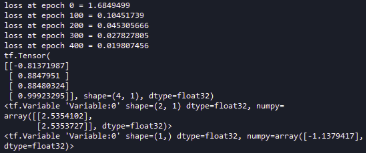

| 개념                          | 역할                          | 핵심 내용                                               |
|-----------------------------|-------------------------------|--------------------------------------------------------|
| 오차 역전파 (Backpropagation) | 기울기 계산                     | 손실 함수를 각 파라미터에 대해 미분 (예: ∂L/∂w, ∂L/∂b)<br>δᵢ = (Wᵢ₊₁)ᵗ × δᵢ₊₁ × f′(zᵢ) |
| 경사 하강법 (Gradient Descent) | 기울기를 이용해 파라미터 업데이트 | w ← w − η × ∂L/∂w                                      |


| 구분 | 질문 내용 또는 착각 | 실제 개념 | 흐름 설명 |
|------|----------------------|------------|-----------|
| ❓질문 1 | "자신의 층에서 이미 기울기 있다고 했는데 왜 i+1층 기울기를 곱하나요?" | 오차역전파는 연쇄법칙 기반. **자신의 로컬 미분(f′(z)) × 위 층의 오차(δ)**로 계산해야 전체 오차 기울기 생성 | 기울기 자체는 **그 층에서 계산**하지만, 오차는 위층에서 전달되어야 **전체 δ 계산 가능** |
| ❓질문 2 | "자신의 층에서의 기울기는 언제 계산되나요?" | 자신의 층에서의 로컬 기울기(예: 활성화 함수의 미분)**는 역전파가 그 층에 도달했을 때 즉시 계산| 순전파 때 저장된 z를 사용해 그 자리에서 f′(z) 계산. 그 후 위층의 δ와 곱해 최종 δ 완성 |
| ❗놓쳤던 개념 | 전체 오차 기울기(δ)는 로컬 × 위쪽 오차 전파로 계산됨 | 로컬 기울기는 있지만, **그 자체만으로는 전체 역전파 방향 못 정함** | 전체 δ 계산에는 항상 **"위에서부터의 영향"**이 포함돼야 함 |
| 💡핵심 개념 | 역전파는 **연쇄법칙 기반의 오차 누적 전달 구조** | δᵢ = (Wᵢ₊₁)ᵗ × δᵢ₊₁ × f′(zᵢ) | 출력층부터 δ를 계산해 역순으로 각 층의 δ 생성 |



In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Keras의 고수준 API를 활용하여 OR 논리 게이트 문제를  
# 단층 퍼셉트론(1개의 Dense 층)으로 학습하는 예제임.  
# 활성화 함수로 tanh를 사용하여 출력 범위를 [-1, 1]로 정규화하며,  
# 손실 함수로는 평균 제곱 오차(MSE)를 사용함.  
# 모델 학습이 완료되면 입력에 대한 예측 결과를 출력함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 입력 및 출력 데이터 정의
# 2단계: NumPy 배열로 변환
# 3단계: Sequential 모델 생성 및 Dense 층 추가
# 4단계: 모델 컴파일 (손실 함수 및 옵티마이저 정의)
# 5단계: 모델 학습 (에폭 수 지정)
# 6단계: 학습된 모델로 예측 수행 및 결과 출력
# ------------------------------------------------------------

from tensorflow.keras.models import Sequential        
# 순차적 딥러닝 모델 구조를 정의하기 위한 클래스 임포트 수행
from tensorflow.keras.layers import Dense             
# 완전 연결(Dense) 층을 구현하는 클래스 임포트 수행
from tensorflow.keras.optimizers import SGD 
# 확률적 경사하강법(Stochastic Gradient Descent) 옵티마이저 임포트 수행
import numpy as np                                    
# 수치 계산과 배열 생성을 위한 NumPy 라이브러리 임포트 수행

# ------------------------------------------------------------
# [1단계] OR 데이터셋 정의
# ------------------------------------------------------------

x = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]  
# OR 게이트의 입력 2차원 벡터 4개를 정의함

y = [[-1], [1], [1], [1]]  
# OR 게이트의 정답 라벨을 정의함
# False → -1, True → 1 형태로 표현함 (tanh에 맞게 -1~1로 정규화됨)

# ------------------------------------------------------------
# [2단계] NumPy 배열 변환
# ------------------------------------------------------------

x = np.array(x)  # 입력 리스트를 NumPy 배열로 변환함 (shape: (4, 2))
y = np.array(y)  # 출력 리스트를 NumPy 배열로 변환함 (shape: (4, 1))

n_input = 2      # 입력 특성의 수를 2로 설정함(입력 피처, 즉 칼럼의 갯수가 2)
n_output = 1     # 출력 노드 수를 1로 설정함

# ------------------------------------------------------------
# [3단계] Keras Sequential 모델 정의
# ------------------------------------------------------------

perceptron = Sequential()  
# 순차적 모델 구조(한 층씩 쌓는 방식)로 모델 객체 생성 수행

perceptron.add(Dense(
    units=n_output,                  # 출력 유닛 수는 1개로 설정함
    activation='tanh',               # 비선형 활성화 함수로 tanh 사용 (-1 ~ 1 범위 출력)
    input_shape=(n_input,),          # 입력 데이터는 2차원 벡터임을 지정함 # 각 샘플은 길이 2인 벡터임 → [x₁, x₂]
    kernel_initializer='random_uniform',  # 가중치 초기값을 균등 분포에서 무작위로 설정함
    bias_initializer='zeros'              # 편향 초기값을 0으로 설정함
))  # 1개의 완전 연결(Dense) 층을 모델에 추가함

# ------------------------------------------------------------
# [4단계] 모델 컴파일
# 모델 컴파일"은 모델이 학습(훈련)을 시작할 수 있도록,
# 손실 함수, 옵티마이저, 평가 지표 등을 설정하는 준비 과정
# ------------------------------------------------------------

perceptron.compile(
    loss='mse',                               # 손실 함수로 평균 제곱 오차(MSE)를 사용함
    optimizer=SGD(learning_rate=0.1),         # SGD 옵티마이저를 학습률 0.1로 설정함
    metrics=['mse']                           # 학습 도중 모니터링할 평가지표로 MSE 사용
)  # 모델을 학습 가능하도록 컴파일함

# ------------------------------------------------------------
# [5단계] 모델 학습 수행
# ------------------------------------------------------------

perceptron.fit(
    x, y,              # 학습에 사용할 입력과 정답 데이터 전달
    epochs=500,        # 총 학습 반복 횟수(에폭 수)를 500으로 설정함
    verbose=2          # 학습 로그 출력 레벨을 간략하게 설정함 (에폭별 손실 출력)
)  # 학습 데이터로 퍼셉트론을 반복 학습함

# ------------------------------------------------------------
# [6단계] 예측 수행 및 출력
# ------------------------------------------------------------

res = perceptron.predict(x)  # 학습된 모델을 사용하여 입력 x에 대한 예측 결과 생성함
print(res)                   # 예측된 출력값을 출력함 (기대값: [[-1], [1], [1], [1]] 근처)

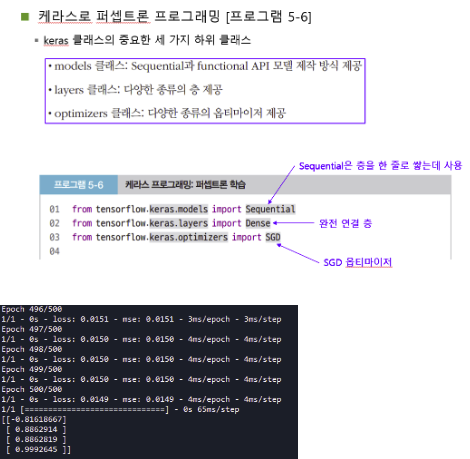

In [ ]:
import numpy as np  # 수치 계산과 배열 처리를 위한 NumPy 라이브러리 임포트 수행
import tensorflow as tf  # 딥러닝 모델 구현 및 학습을 위한 TensorFlow 라이브러리 임포트 수행
from tensorflow.keras.datasets import mnist  # Keras에서 제공하는 MNIST 데이터셋 로더 임포트 수행

from tensorflow.keras.models import Sequential  # 층을 순차적으로 쌓는 신경망 모델 클래스 임포트 수행
from tensorflow.keras.layers import Dense  # 완전 연결(Dense) 층을 구현하는 클래스 임포트 수행
from tensorflow.keras.optimizers import Adam  # Adam 옵티마이저 클래스를 임포트하여 학습 알고리즘 설정 수행

# -----------------------------------------------
# [1단계] MNIST 데이터셋을 로딩하고 전처리 수행
# -----------------------------------------------

(x_train, y_train), (x_test, y_test) = mnist.load_data()  
# MNIST 손글씨 이미지 데이터를 학습용(x_train, y_train)과 테스트용(x_test, y_test)으로 로딩 수행
# x_train의 shape: (60000, 28, 28), y_train의 shape: (60000,)
# x_test의 shape: (10000, 28, 28), y_test의 shape: (10000,)

x_train = x_train.reshape(60000, 784)  
# 28x28 크기의 이미지를 1차원 배열(벡터)로 평탄화하여 shape=(60000, 784)로 변환 수행

x_test = x_test.reshape(10000, 784)  
# 테스트셋도 동일하게 1차원 벡터로 평탄화하여 shape=(10000, 784)로 변환 수행

x_train = x_train.astype(np.float32) / 255.0  
# 학습용 이미지 데이터를 float32 형으로 변환 후 255로 나누어 정규화 수행
# 픽셀 값을 [0,1] 범위로 스케일링하여 학습 안정성과 속도 향상 도모

x_test = x_test.astype(np.float32) / 255.0  
# 테스트 이미지 데이터도 동일하게 정규화 수행

y_train = tf.keras.utils.to_categorical(y_train, 10)  
# 학습 라벨 데이터를 원-핫 인코딩 방식으로 변환 수행
# 정수형 라벨(0~9)을 10차원 이진 벡터로 표현 → shape=(60000, 10)

y_test = tf.keras.utils.to_categorical(y_test, 10)  
# 테스트 라벨 데이터도 동일하게 원-핫 인코딩 적용 수행 → shape=(10000, 10)

# -----------------------------------------------
# [2단계] 다층 퍼셉트론(Multilayer Perceptron) 모델 구성
# -----------------------------------------------

n_input = 784       # 입력층 노드 수 설정 (28x28=784 차원)
n_hidden = 1024     # 은닉층 노드 수 설정 (임의로 지정한 1024 유닛)
n_output = 10       # 출력층 노드 수 설정 (분류 클래스 0~9까지 총 10개)

mlp = Sequential()  # 층을 순차적으로 쌓는 방식의 모델 객체 생성 수행

mlp.add(Dense(
    units=n_hidden,                      # 은닉층 유닛 수를 1024로 설정
    activation='tanh',                   # tanh 함수 사용 → 출력 범위를 [-1, 1]로 설정
    input_shape=(n_input,),              # 입력 벡터의 shape을 (784,)로 지정
    kernel_initializer='random_uniform', # 가중치 초기화 방식을 균등분포로 설정
    bias_initializer='zeros'             # 편향을 0으로 초기화
))  # 첫 번째 Dense 은닉층을 모델에 추가

mlp.add(Dense(
    units=n_output,                      # 출력층 유닛 수는 분류 클래스 수인 10으로 설정
    activation='tanh',         # tanh 활성화 함수 사용 → softmax 대신 tanh 사용 시 확률 대신 실수 출력
    kernel_initializer='random_uniform',
    bias_initializer='zeros'
))  # 두 번째 Dense 출력층을 모델에 추가

# -----------------------------------------------
# [3단계] 모델 컴파일 설정
# -----------------------------------------------

mlp.compile(
    loss='mean_squared_error',              # 손실 함수로 평균 제곱 오차(MSE) 사용
    optimizer=Adam(learning_rate=0.001),    # Adam 옵티마이저 사용, 학습률은 0.001로 설정
    metrics=['accuracy']                    # 평가 지표로 정확률(accuracy) 사용
)  # 모델 학습에 필요한 손실 함수, 옵티마이저, 평가 기준을 설정 수행

# -----------------------------------------------
# [4단계] 모델 학습 수행
# -----------------------------------------------

hist = mlp.fit(
    x_train, y_train,                      # 입력 데이터와 정답 라벨을 학습에 사용
    batch_size=128,                        # 배치 크기를 128로 설정 (1 에폭 내에서 128개씩 묶어 학습)
    epochs=30,                             # 학습 반복 횟수를 30 에폭으로 설정
    validation_data=(x_test, y_test),     # 검증 데이터로 테스트셋 지정
    verbose=2                              # 학습 상태 출력 형식을 간략하게 설정
)  # 학습 과정의 정확률, 손실 등은 hist 객체에 저장됨

# -----------------------------------------------
# [5단계] 테스트셋을 통한 모델 평가
# -----------------------------------------------

res = mlp.evaluate(x_test, y_test, verbose=0)  
# 테스트 데이터를 이용해 학습된 모델의 성능을 평가
# 반환값: [손실 값, 정확률]

print("정확률은", res[1] * 100)  
# 정확률 값을 백분율로 환산하여 출력 수행

# -----------------------------------------------
# [6단계] 학습 결과 시각화
# -----------------------------------------------

import matplotlib.pyplot as plt  # 시각화 라이브러리 matplotlib의 pyplot 모듈 임포트

# 정확률 변화 곡선 시각화
plt.plot(hist.history['accuracy'])            # 학습 정확률 값의 변화 추이 시각화
plt.plot(hist.history['val_accuracy'])        # 검증 정확률 값의 변화 추이 시각화
plt.title('Model accuracy')                   # 그래프 제목 설정
plt.ylabel('Accuracy')                        # y축 레이블 설정
plt.xlabel('Epoch')                           # x축 레이블 설정
plt.legend(['Train', 'Validation'], loc='upper left')  # 범례 설정
plt.grid()                                    # 격자선 표시 설정
plt.show()                                    # 정확률 그래프 출력

# 손실 함수 변화 곡선 시각화
plt.plot(hist.history['loss'])                # 학습 손실 값의 변화 추이 시각화
plt.plot(hist.history['val_loss'])            # 검증 손실 값의 변화 추이 시각화
plt.title('Model loss')                       # 그래프 제목 설정
plt.ylabel('Loss')                            # y축 레이블 설정
plt.xlabel('Epoch')                           # x축 레이블 설정
plt.legend(['Train', 'Validation'], loc='upper right')  # 범례 설정
plt.grid()                                    # 격자선 표시 설정
plt.show()                                    # 손실 곡선 출력


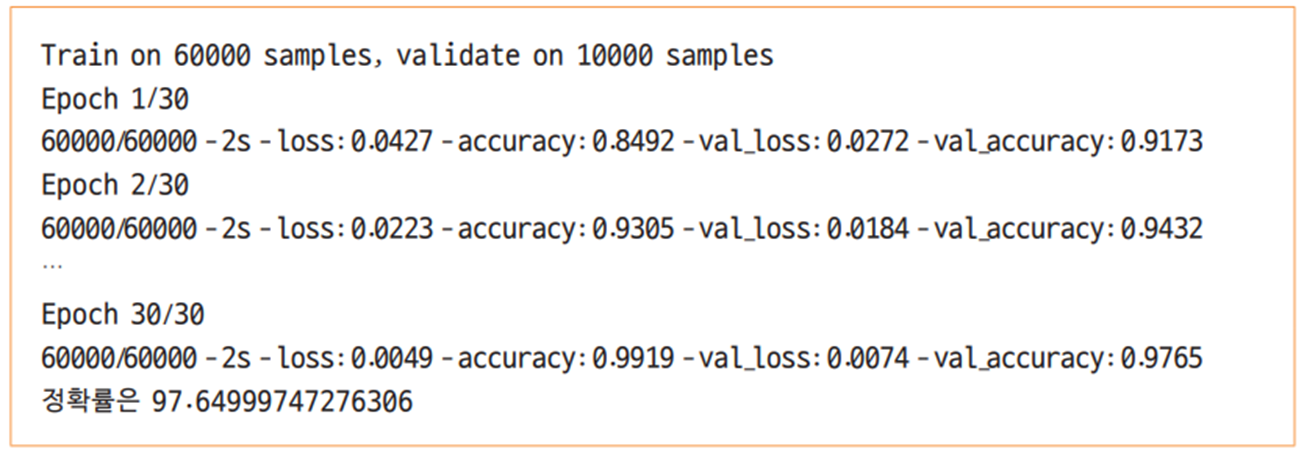

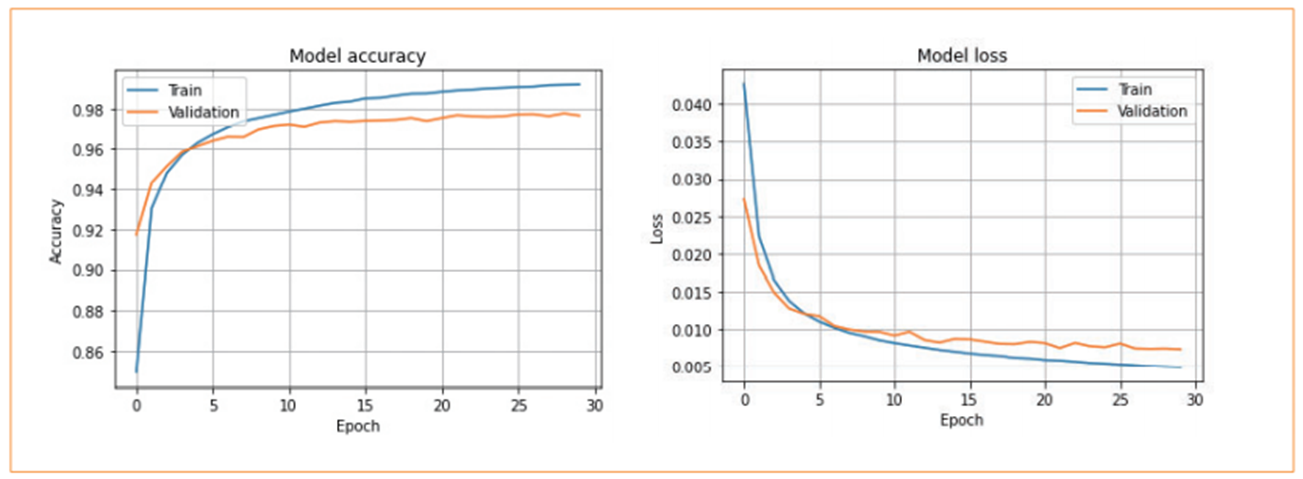

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Fashion MNIST 의류 이미지 분류 문제를 해결하기 위한
# 다층 퍼셉트론(Multi-Layer Perceptron, MLP) 모델을 TensorFlow + Keras를 이용하여 구현한 예제임
# 입력층(784), 은닉층(1024, tanh), 출력층(10, softmax)의 구조로 구성되며
# 손실 함수로 categorical_crossentropy, 옵티마이저로 Adam을 사용하여 학습을 수행함
# 학습 및 검증 정확도/손실의 변화 곡선을 통해 학습 효과와 과적합 여부를 시각적으로 확인함
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Processing Flow]
# 1단계: Fashion MNIST 데이터셋 로딩
# 2단계: 입력 이미지 벡터화 및 정규화, 라벨 원-핫 인코딩 수행
# 3단계: MLP 모델 구성 (784 -> 1024(tanh) -> 10(softmax))
# 4단계: 모델 컴파일 및 학습 수행 (optimizer=Adam, loss=categorical_crossentropy)
# 5단계: 테스트셋 성능 평가 및 정확도 출력
# 6단계: 학습 및 검증 정확도/손실 시각화 수행
# ------------------------------------------------------------

import numpy as np  # 수치 연산을 위한 numpy 라이브러리 임포트 수행
import tensorflow as tf  # 텐서 연산 및 모델 구현을 위한 tensorflow 라이브러리 임포트 수행
from tensorflow.keras.datasets import fashion_mnist  # 패션 MNIST 데이터셋 로더 임포트 수행
from tensorflow.keras.models import Sequential  # 순차적 신경망 모델 생성을 위한 클래스 임포트 수행
from tensorflow.keras.layers import Dense  # 완전 연결(Dense) 층을 위한 클래스 임포트 수행
from tensorflow.keras.optimizers import Adam  # Adam 최적화 알고리즘을 위한 클래스 임포트 수행
import matplotlib.pyplot as plt  # 학습 시각화를 위한 matplotlib의 pyplot 모듈 임포트 수행

# 1. Fashion MNIST 데이터셋 로딩
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()  # 학습용/테스트용 데이터셋 로딩 수행

# 2. 입력 데이터 전처리
x_train = x_train.reshape(60000, 784).astype(np.float32) / 255.0  
# 28x28 이미지를 784차원 벡터로 변환 후 [0,1]로 정규화 수행
x_test = x_test.reshape(10000, 784).astype(np.float32) / 255.0  
# 테스트셋도 동일한 방식으로 전처리 수행

# 3. 라벨 데이터를 원-핫 인코딩으로 변환 수행
y_train = tf.keras.utils.to_categorical(y_train, 10)  # 정수 라벨을 10차원 이진 벡터로 변환 수행
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 라벨도 동일하게 변환 수행

# 4. 모델 파라미터 정의
n_input = 784      # 입력층 노드 수 정의 (28x28 = 784)
n_hidden = 1024    # 은닉층 뉴런 수 정의 (1024 유닛)
n_output = 10      # 출력층 노드 수 정의 (클래스 수 10)

# 5. MLP 모델 구성
mlp = Sequential()  # 순차적 모델 객체 생성 수행

mlp.add(Dense(units=n_hidden, activation='tanh',  # 은닉층 추가: 1024 유닛, tanh 활성화 함수 사용
              input_shape=(n_input,),  # 입력 벡터 형상 정의 (784,)
              kernel_initializer='random_uniform',  # 가중치 초기화를 균등분포로 설정
              bias_initializer='zeros'))  # 편향을 0으로 초기화 수행

mlp.add(Dense(units=n_output, activation='softmax',  # 출력층 추가: 10 유닛, softmax 함수로 클래스별 확률 출력
              kernel_initializer='random_uniform',
              bias_initializer='zeros'))

# 6. 모델 컴파일 설정 수행
mlp.compile(loss='categorical_crossentropy',  
            # 손실 함수로 categorical_crossentropy 사용 (softmax + one-hot에 적합)
            optimizer=Adam(learning_rate=0.001),  # Adam 옵티마이저 사용, 학습률 0.001로 설정
            metrics=['accuracy'])  # 평가 지표로 정확도 사용

# 7. 모델 학습 수행
hist = mlp.fit(x_train, y_train,  # 입력과 출력 데이터를 모델에 전달하여 학습 수행
               batch_size=128,  # 128개씩 묶어 한 번에 학습
               epochs=30,  # 총 30번 반복 학습 수행
               validation_data=(x_test, y_test),  # 테스트 데이터를 검증셋으로 지정
               verbose=2)  # 학습 상태 간단 요약 정보 출력

# 8. 테스트셋 평가 수행
res = mlp.evaluate(x_test, y_test, verbose=0)  # 테스트셋에 대한 손실과 정확도 평가 수행
print("\n최종 테스트 정확률은", res[1] * 100, "%입니다.")  # 정확도 출력

# 9. 정확도 변화 시각화
plt.plot(hist.history['accuracy'])  # 학습 정확도 그래프 그리기
plt.plot(hist.history['val_accuracy'])  # 검증 정확도 그래프 그리기
plt.title('Model Accuracy over Epochs')  # 그래프 제목 설정
plt.ylabel('Accuracy')  # y축 라벨 설정
plt.xlabel('Epoch')  # x축 라벨 설정
plt.legend(['Train', 'Validation'], loc='upper left')  # 범례 추가
plt.grid()  # 격자 표시 수행
plt.show()  # 정확도 그래프 출력 수행

# 10. 손실 변화 시각화
plt.plot(hist.history['loss'])  # 학습 손실 그래프 그리기
plt.plot(hist.history['val_loss'])  # 검증 손실 그래프 그리기
plt.title('Model Loss over Epochs')  # 그래프 제목 설정
plt.ylabel('Loss')  # y축 라벨 설정
plt.xlabel('Epoch')  # x축 라벨 설정
plt.legend(['Train', 'Validation'], loc='upper right')  # 범례 추가
plt.grid()  # 격자 표시 수행
plt.show()  # 손실 그래프 출력 수행


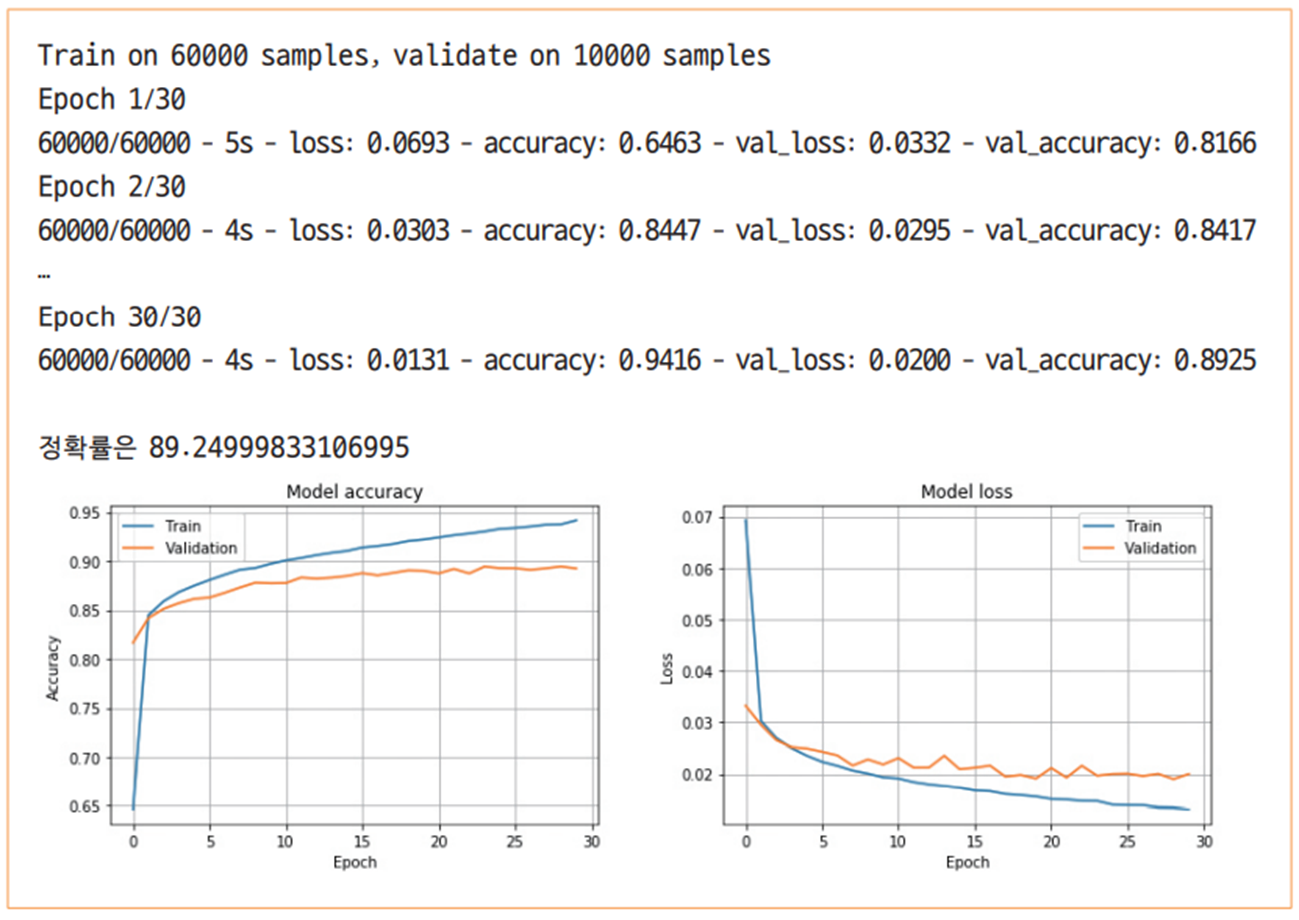

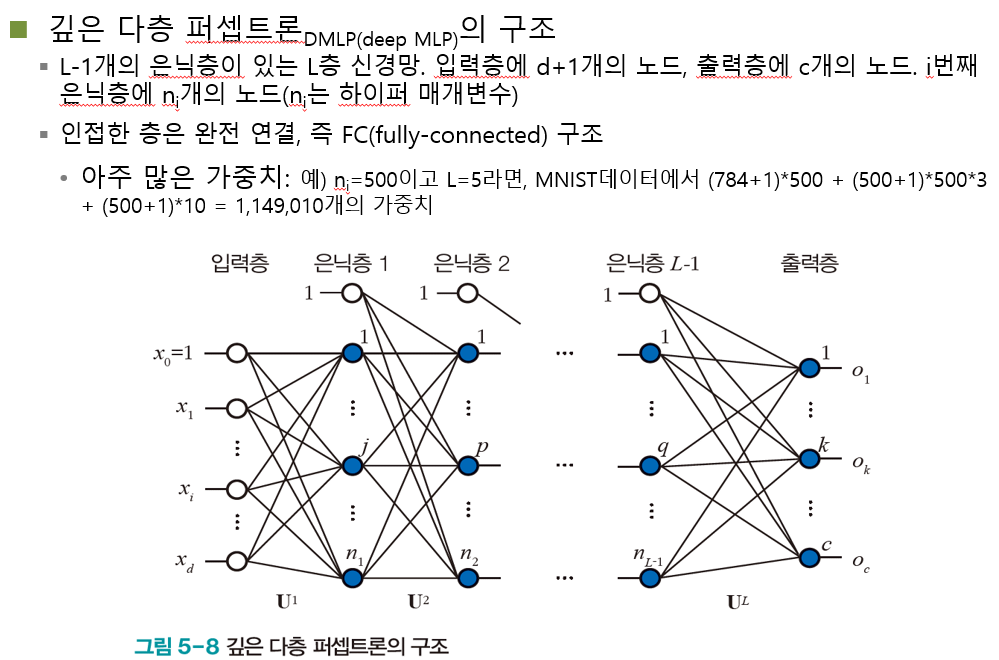

- 연결 방식: 완전 연결(Fully Connected)
각 노드는 이전 층의 모든 노드와 연결.

즉,

> 입력층 → 은닉층 1: (입력 노드 수 + 1) × 은닉 노드 수

> 은닉층 1 → 은닉층 2: (은닉 노드 수 + 1) × 다음 은닉 노드 수

> 은닉층 L−1 → 출력층: (은닉 노드 수 + 1) × 출력 노드 수


예시: MNIST에서 파라미터 수 계산

MNIST: 입력 784개 (28×28 이미지), 출력 10개 (0~9 숫자 분류)

은닉층: 노드 수 500개, 총 4개층이라 가정

| 층 연결 구조             | 계산식                        | 파라미터 수 |
|--------------------------|-------------------------------|-------------|
| 입력층 → 은닉층 1        | (784 + 1) × 500               | 392,500     |
| 은닉층 1 → 은닉층 2      | (500 + 1) × 500               | 250,500     |
| 은닉층 2 → 은닉층 3      | (500 + 1) × 500               | 250,500     |
| 은닉층 3 → 은닉층 4      | (500 + 1) × 500               | 250,500     |
| 은닉층 4 → 출력층        | (500 + 1) × 10                | 5,010       |
| **총합**                 |                               | **1,149,510** |



In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 MNIST 손글씨 숫자 데이터셋을 기반으로 MLP (Multi-Layer Perceptron) 신경망을 구성하여
# 숫자를 분류하는 모델을 학습하고 평가하는 예제 코드임.
# 총 4개의 은닉층을 포함한 심층 신경망 구조를 사용하며, 활성화 함수는 tanh,
# 손실 함수는 평균제곱오차(MSE)를 사용하여 다중 클래스 분류 문제를 해결함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 임포트
# 2단계: MNIST 데이터셋 로드 및 전처리 (정규화, reshape, one-hot 인코딩)
# 3단계: 신경망 구조 정의 (입력층, 은닉층 4개, 출력층)
# 4단계: 신경망 컴파일 및 학습 수행
# 5단계: 테스트셋을 통한 정확률 평가
# 6단계: 학습 정확률 및 손실 변화 시각화
# ------------------------------------------------------------

import numpy as np  # 수치 계산 및 배열 처리를 위한 numpy 라이브러리 임포트
import tensorflow as tf  # 딥러닝 모델 구현을 위한 TensorFlow 프레임워크 임포트
from tensorflow.keras.datasets import mnist  # MNIST 데이터셋 로드를 위한 모듈 임포트
from tensorflow.keras.models import Sequential  # 순차적 모델 생성을 위한 클래스 임포트
from tensorflow.keras.layers import Dense  # 완전 연결층(Dense layer) 클래스 임포트
from tensorflow.keras.optimizers import Adam  # Adam 최적화 알고리즘 클래스 임포트

# ------------------------------------------------------------
# [1단계] MNIST 데이터셋 로드 및 전처리
# ------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = mnist.load_data()  # 훈련/테스트 이미지 및 레이블 로드

x_train = x_train.reshape(60000, 784)  # 28x28 이미지를 1차원 벡터(784차원)로 변환
x_test = x_test.reshape(10000, 784)  # 테스트 이미지에 대해서도 동일한 변환 수행

x_train = x_train.astype(np.float32) / 255.0  # 훈련 데이터를 실수형으로 변환 후 0~1 범위로 정규화
x_test = x_test.astype(np.float32) / 255.0  # 테스트 데이터 정규화

y_train = tf.keras.utils.to_categorical(y_train, 10)  # 훈련 레이블을 one-hot 벡터로 변환
y_test = tf.keras.utils.to_categorical(y_test, 10)  # 테스트 레이블을 one-hot 벡터로 변환

# ------------------------------------------------------------
# [2단계] 신경망 구조 정의
# ------------------------------------------------------------

n_input = 784  # 입력 뉴런 수: 28x28 이미지의 픽셀 수
n_hidden1 = 1024  # 첫 번째 은닉층 뉴런 수
n_hidden2 = 512  # 두 번째 은닉층 뉴런 수
n_hidden3 = 512  # 세 번째 은닉층 뉴런 수
n_hidden4 = 512  # 네 번째 은닉층 뉴런 수
n_output = 10  # 출력 뉴런 수: 0~9까지 총 10개 클래스

mlp = Sequential()  # 순차적 레이어를 구성하기 위한 모델 생성

# 첫 번째 은닉층: tanh 활성화, 가중치 초기화는 균등 분포, 편향은 0으로 초기화
mlp.add(Dense(units=n_hidden1, activation='tanh', input_shape=(n_input,),
              kernel_initializer='random_uniform', bias_initializer='zeros'))

# 두 번째 은닉층
mlp.add(Dense(units=n_hidden2, activation='tanh',
              kernel_initializer='random_uniform', bias_initializer='zeros'))

# 세 번째 은닉층
mlp.add(Dense(units=n_hidden3, activation='tanh',
              kernel_initializer='random_uniform', bias_initializer='zeros'))

# 네 번째 은닉층
mlp.add(Dense(units=n_hidden4, activation='tanh',
              kernel_initializer='random_uniform', bias_initializer='zeros'))

# 출력층: 10개 클래스에 대해 tanh 함수를 통해 출력
mlp.add(Dense(units=n_output, activation='tanh',
              kernel_initializer='random_uniform', bias_initializer='zeros'))

# ------------------------------------------------------------
# [3단계] 신경망 학습
# ------------------------------------------------------------

# 손실 함수는 평균 제곱 오차, 최적화 알고리즘은 Adam, 평가 지표는 정확률로 설정
mlp.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# 모델 학습 수행: 배치 크기 128, 에폭 수 30, 검증 데이터는 테스트셋 사용
hist = mlp.fit(x_train, y_train, batch_size=128, epochs=30,
               validation_data=(x_test, y_test), verbose=2)

# ------------------------------------------------------------
# [4단계] 테스트 데이터셋 정확률 평가
# ------------------------------------------------------------

res = mlp.evaluate(x_test, y_test, verbose=0)  # 테스트셋으로 평가 수행 (손실, 정확률 반환)
print("정확률은", res[1] * 100)  # 정확률을 백분율로 변환하여 출력

import matplotlib.pyplot as plt  # 학습 결과 시각화를 위한 matplotlib 라이브러리 임포트

# ------------------------------------------------------------
# [5단계] 정확률 시각화
# ------------------------------------------------------------

plt.plot(hist.history['accuracy'])  # 훈련 정확률 그래프
plt.plot(hist.history['val_accuracy'])  # 검증 정확률 그래프
plt.title('Model accuracy')  # 그래프 제목
plt.ylabel('Accuracy')  # y축 레이블
plt.xlabel('Epoch')  # x축 레이블
plt.legend(['Train', 'Validation'], loc='upper left')  # 범례 위치 설정
plt.grid()  # 격자 표시
plt.show()  # 정확률 곡선 시각화

# ------------------------------------------------------------
# [6단계] 손실 함수 시각화
# ------------------------------------------------------------

plt.plot(hist.history['loss'])  # 훈련 손실 그래프
plt.plot(hist.history['val_loss'])  # 검증 손실 그래프
plt.title('Model loss')  # 그래프 제목
plt.ylabel('Loss')  # y축 레이블
plt.xlabel('Epoch')  # x축 레이블
plt.legend(['Train', 'Validation'], loc='upper right')  # 범례 위치 설정
plt.grid()  # 격자 표시
plt.show()  # 손실 곡선 시각화


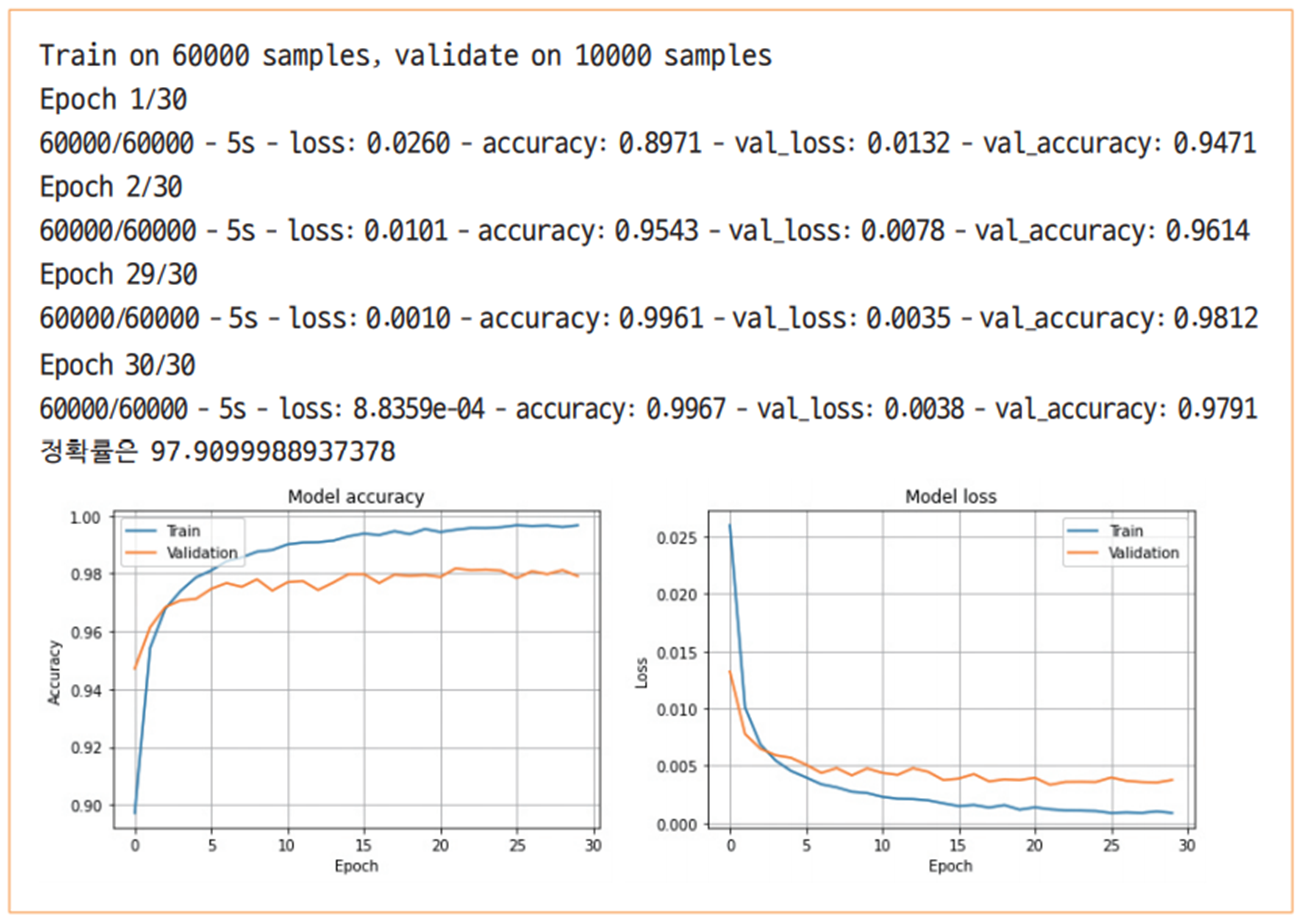

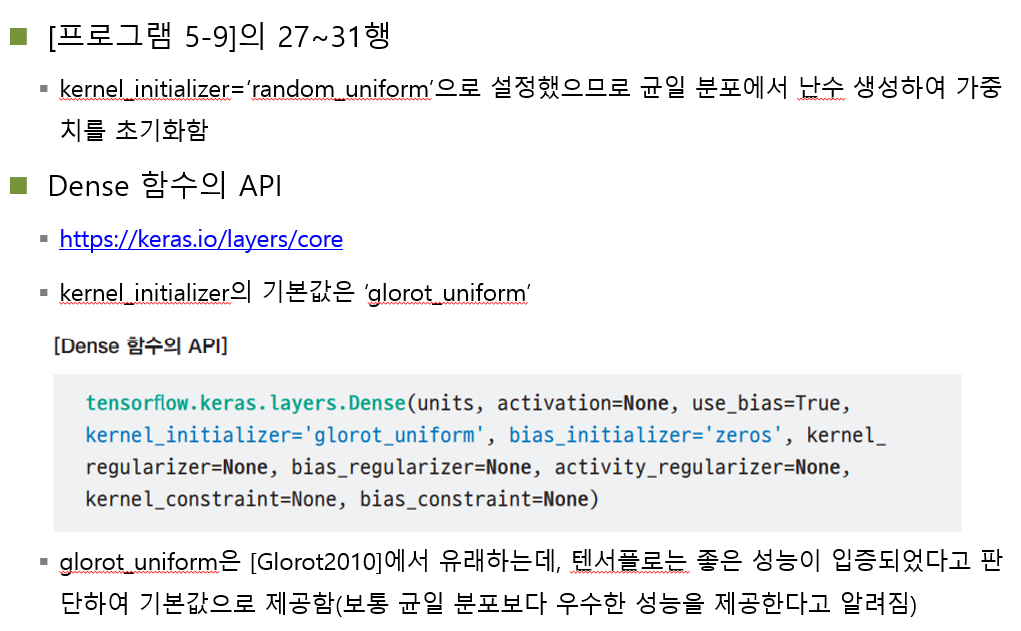

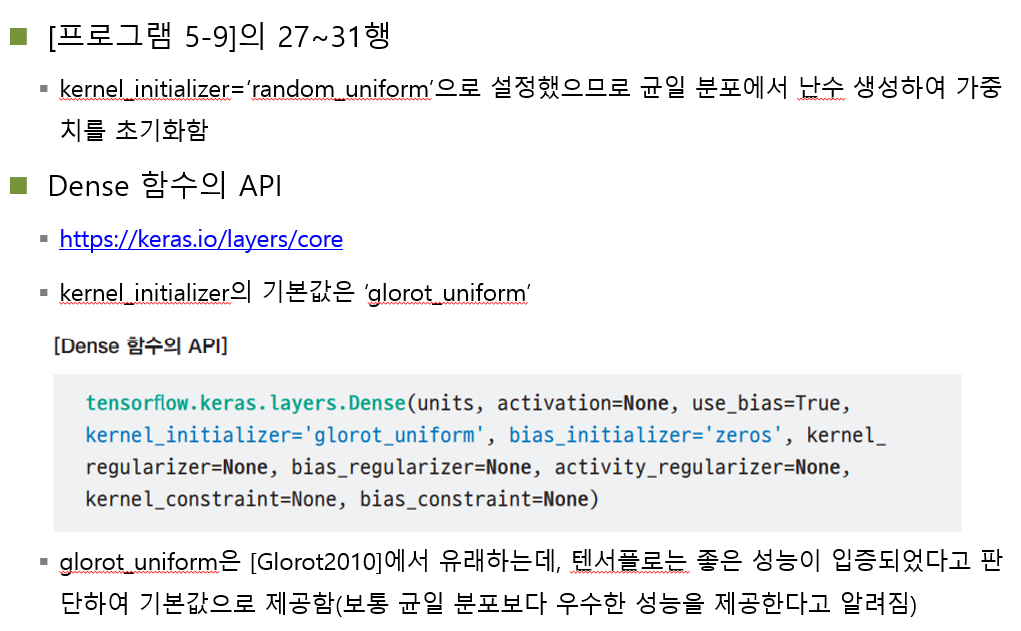

| 문제 유형     | 손실 함수                        | 특성                              |
|---------------|----------------------------------|-----------------------------------|
| 회귀          | MSE (Mean Squared Error)         | 이상치 민감, 일반적              |
| 회귀          | MAE (Mean Absolute Error)        | 이상치에 덜 민감                 |
| 회귀          | Huber Loss                        | MSE + MAE 장점 결합              |
| 이진 분류     | Binary Cross Entropy             | 시그모이드 + 확률 예측           |
| 다중 분류     | Categorical Cross Entropy        | 소프트맥스 + one-hot 정답        |
| 다중 분류     | Sparse Categorical Cross Entropy | 정수 라벨 사용 가능              |
| 불균형 분류   | Focal Loss                        | 어려운 샘플에 집중               |
| 랭킹/분류     | Hinge Loss                        | SVM에서 사용                     |


In [ ]:
# ---------------------------------------------------------------
# [전체 개요: 평균제곱오차 vs 교차 엔트로피 손실 함수 비교 실험]
#
# 목적:
# 동일한 MLP 모델 구조에서 손실 함수만 다르게 설정하여,
# 다중 클래스 분류 문제에서 평균제곱오차(MSE)와 범주형 교차 엔트로피(CE)가
# 학습 성능에 미치는 영향을 실험적으로 비교하고 분석함
#
# 실험 조건:
# - 데이터셋: MNIST (손글씨 숫자 0~9)
# - 모델 구조: 4개의 은닉층을 포함한 MLP
# - 활성화 함수: 은닉층은 tanh, 출력층은 softmax
# - 손실 함수: 실험 조건에 따라 MSE 또는 CE 사용
# - 옵티마이저, 초기화 방식, 학습률, 배치 크기 등은 모두 동일하게 설정
# - 결과 비교: 테스트 정확률과 학습 곡선을 하나의 그래프에서 시각화
# ---------------------------------------------------------------

# ---------------------------------------------------------------
# [처리 흐름 요약]
# 1단계: 라이브러리 및 데이터셋 로딩
# 2단계: 입력 이미지 및 정답 레이블 전처리 (정규화 및 one-hot 인코딩)
# 3단계: MLP 모델 구조 정의 및 손실 함수에 따른 학습 수행 (MSE vs CE)
# 4단계: 테스트셋 평가 및 정확률 비교
# 5단계: 두 모델의 학습 정확도 곡선을 하나의 그래프에서 시각화
# ---------------------------------------------------------------

import numpy as np  # 벡터 연산 및 수치 계산을 위한 배열 기반 라이브러리 임포트
import tensorflow as tf  # 딥러닝 모델 설계 및 학습 실행을 위한 텐서 연산 프레임워크 임포트
from tensorflow.keras.datasets import mnist  # MNIST 데이터셋을 로드하기 위한 모듈 임포트
from tensorflow.keras.models import Sequential  # 레이어를 순차적으로 구성하기 위한 모델 클래스 임포트
from tensorflow.keras.layers import Dense  # 완전 연결층(Dense layer) 정의를 위한 레이어 클래스 임포트
from tensorflow.keras.optimizers import Adam  # 가중치 최적화를 위한 Adam 옵티마이저 클래스 임포트

# ---------------------------------------------------------------
# [1단계] MNIST 데이터셋 로딩 및 전처리
# ---------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = mnist.load_data() 
# 학습용 60,000개, 테스트용 10,000개 이미지 및 정답 로드

x_train = x_train.reshape(60000, 784)  
# 28x28 이미지를 1차원 벡터(784차원)로 변환하여 Dense 층에 입력 가능하게 변환
x_test = x_test.reshape(10000, 784)  
# 테스트셋에 대해서도 동일한 텐서 구조 변환 수행

x_train = x_train.astype(np.float32) / 255.0  
# 입력 픽셀 값을 0~1 범위로 정규화하여 학습 안정성 향상 유도
x_test = x_test.astype(np.float32) / 255.0  
# 테스트 이미지에 대해서도 동일한 정규화 수행

y_train = tf.keras.utils.to_categorical(y_train, 10) 
# 정답 레이블을 one-hot 인코딩하여 softmax와 호환되도록 변환
y_test = tf.keras.utils.to_categorical(y_test, 10)  
# 테스트 정답도 동일하게 one-hot 벡터로 변환

# ---------------------------------------------------------------
# [2단계] MLP 모델 구조 정의 (은닉층 4개 구성)
# ---------------------------------------------------------------

n_input = 784  # 입력층 차원 수 정의: 28x28 이미지의 총 픽셀 수
n_hidden1 = 1024  # 첫 번째 은닉층의 뉴런 수 정의
n_hidden2 = 512  # 두 번째 은닉층의 뉴런 수 정의
n_hidden3 = 512  # 세 번째 은닉층의 뉴런 수 정의
n_hidden4 = 512  # 네 번째 은닉층의 뉴런 수 정의
n_output = 10  # 출력층 뉴런 수 정의: 0~9까지 10개의 클래스 분류

# ---------------------------------------------------------------
# [3단계] 평균제곱오차(MSE)를 사용한 모델 구성 및 학습
# ---------------------------------------------------------------

dmlp_mse = Sequential()  # 평균제곱오차 손실을 사용하는 MLP 모델 생성

dmlp_mse.add(Dense(units=n_hidden1, activation='tanh', input_shape=(n_input,)))  # 첫 번째 은닉층 추가
dmlp_mse.add(Dense(units=n_hidden2, activation='tanh'))  # 두 번째 은닉층 추가
dmlp_mse.add(Dense(units=n_hidden3, activation='tanh'))  # 세 번째 은닉층 추가
dmlp_mse.add(Dense(units=n_hidden4, activation='tanh'))  # 네 번째 은닉층 추가
dmlp_mse.add(Dense(units=n_output, activation='softmax'))  # 출력층 구성: 클래스 확률 출력을 위한 softmax 사용

# 손실 함수는 평균제곱오차 사용 → 일반적으로 회귀에 적합하나 분류에 대한 비교 실험 목적상 사용
dmlp_mse.compile(
                loss='mean_squared_error', 
                optimizer=Adam(learning_rate=0.0001),
                metrics=['accuracy']
                 )  
# 컴파일 수행

# 평균제곱오차 모델 학습 수행
hist_mse = dmlp_mse.fit(x_train, y_train, batch_size=128, epochs=30, validation_data=(x_test, y_test), verbose=2)

# ---------------------------------------------------------------
# [4단계] 범주형 교차 엔트로피(Cross Entropy)를 사용한 모델 구성 및 학습
# ---------------------------------------------------------------

dmlp_ce = Sequential()  # 교차 엔트로피 손실을 사용하는 MLP 모델 생성

dmlp_ce.add(Dense(units=n_hidden1, activation='tanh', input_shape=(n_input,)))  # 첫 번째 은닉층 추가
dmlp_ce.add(Dense(units=n_hidden2, activation='tanh'))  # 두 번째 은닉층 추가
dmlp_ce.add(Dense(units=n_hidden3, activation='tanh'))  # 세 번째 은닉층 추가
dmlp_ce.add(Dense(units=n_hidden4, activation='tanh'))  # 네 번째 은닉층 추가
dmlp_ce.add(Dense(units=n_output, activation='softmax'))  # 출력층 구성

# 손실 함수는 categorical_crossentropy 사용 → 다중 클래스 분류 문제에 가장 적합한 표준 손실 함수
dmlp_ce.compile(
                loss='categorical_crossentropy', 
                optimizer=Adam(learning_rate=0.0001), 
                metrics=['accuracy']
                )  # 컴파일 수행

# 교차 엔트로피 모델 학습 수행
hist_ce = dmlp_ce.fit(
                    x_train, 
                    y_train, 
                    batch_size=128, 
                    epochs=30, 
                    validation_data=(x_test, y_test), 
                    verbose=2
)

# ---------------------------------------------------------------
# [5단계] 두 모델의 테스트셋 정확률 비교
# ---------------------------------------------------------------

res_mse = dmlp_mse.evaluate(x_test, y_test, verbose=0)  # 평균제곱오차 모델 테스트셋 평가
print("평균제곱오차의 정확률은", res_mse[1] * 100)  # 정확률을 백분율로 출력

res_ce = dmlp_ce.evaluate(x_test, y_test, verbose=0)  # 교차 엔트로피 모델 테스트셋 평가
print("교차 엔트로피의 정확률은", res_ce[1] * 100)  # 정확률을 백분율로 출력

# ---------------------------------------------------------------
# [6단계] 두 모델의 학습 곡선(정확률 변화) 비교 시각화
# ---------------------------------------------------------------

import matplotlib.pyplot as plt  # 학습 곡선 시각화를 위한 matplotlib 임포트

plt.plot(hist_mse.history['accuracy'])  # 평균제곱오차 모델의 훈련 정확률 시각화
plt.plot(hist_mse.history['val_accuracy'])  # 평균제곱오차 모델의 검증 정확률 시각화
plt.plot(hist_ce.history['accuracy'])  # 교차 엔트로피 모델의 훈련 정확률 시각화
plt.plot(hist_ce.history['val_accuracy'])  # 교차 엔트로피 모델의 검증 정확률 시각화

plt.title('Model accuracy comparison between MSE and cross entropy')  # 그래프 제목 설정
plt.ylabel('Accuracy')  # y축 라벨 설정
plt.xlabel('Epoch')  # x축 라벨 설정
plt.legend(['Train_mse', 'Validation_mse', 'Train_ce', 'Validation_ce'], loc='best')  # 범례 설정
plt.grid()  # 격자 표시 활성화
plt.show()  # 시각화 결과 출력


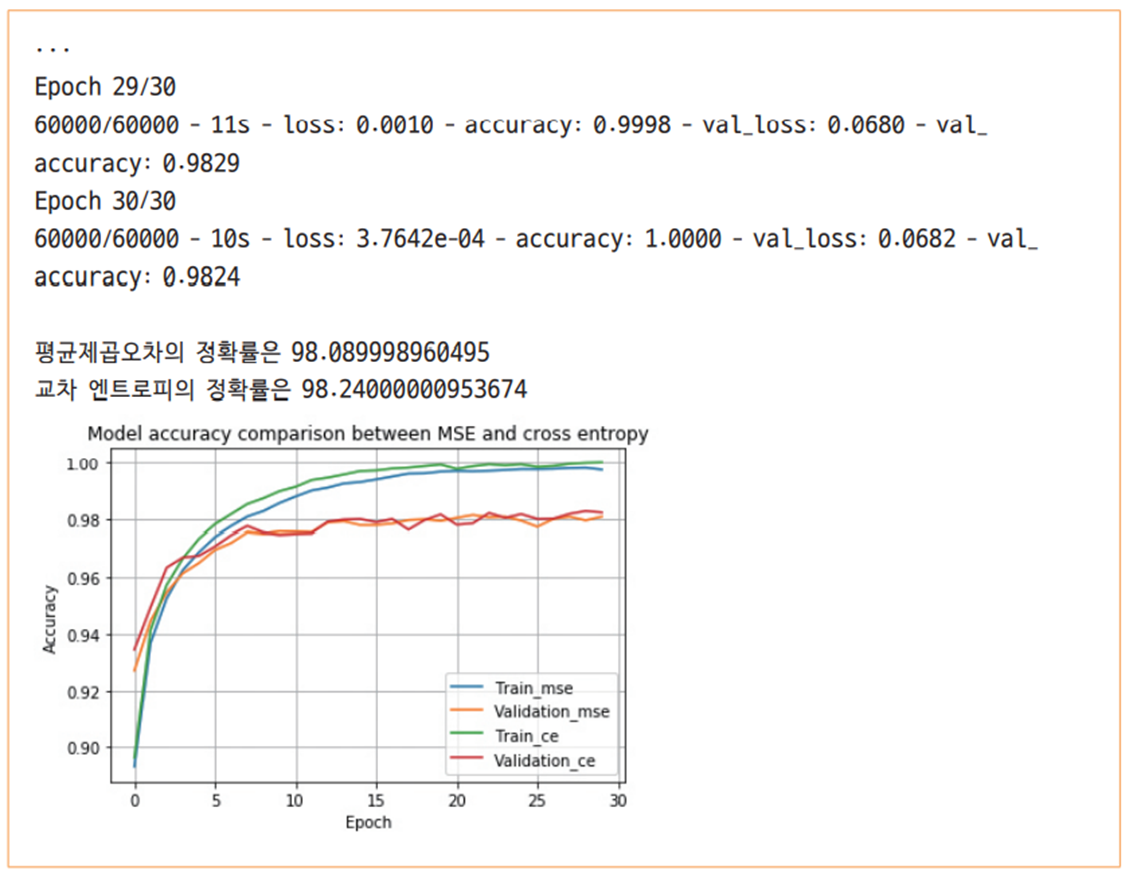

In [1]:
import tensorflow as tf

print("버전:", tf.__version__)
print("GPU 디바이스:", tf.config.list_physical_devices('GPU'))


버전: 2.16.2
GPU 디바이스: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


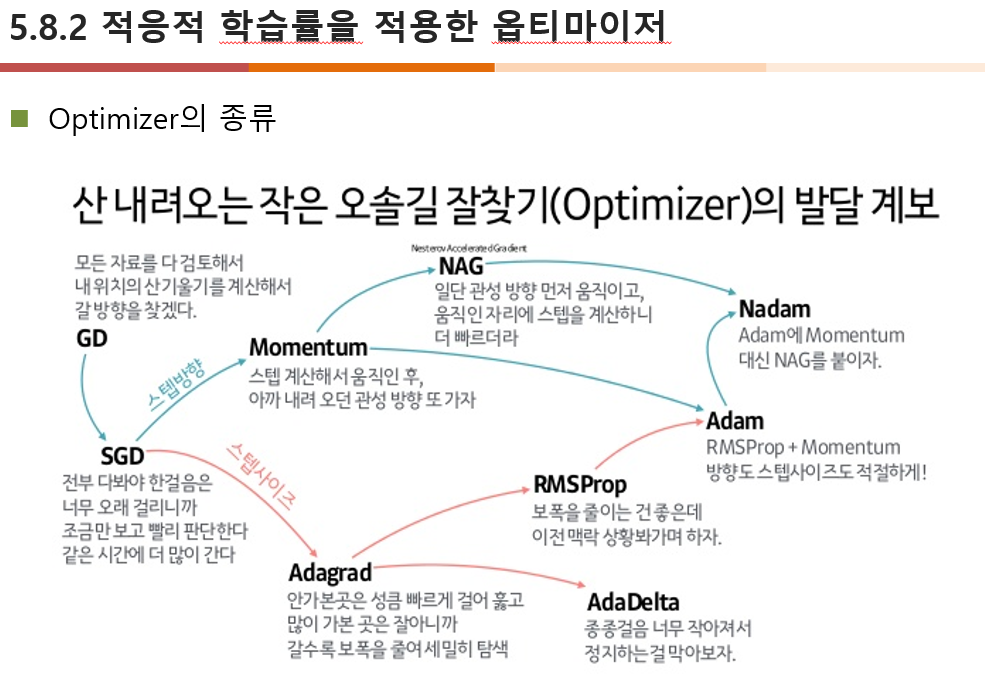

/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-11 02:35:30.159832: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-04-11 02:35:30.159868: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-04-11 02:35:30.159872: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2025-04-11 02:35:30.159909: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-11 02:35:30.159921: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_fac

SGD 옵티마이저의 평균 정확도: 0.7918500105539957
Adam 옵티마이저의 평균 정확도: 0.8745833436648051
Adagrad 옵티마이저의 평균 정확도: 0.7321333289146423
RMSprop 옵티마이저의 평균 정확도: 0.8475666642189026


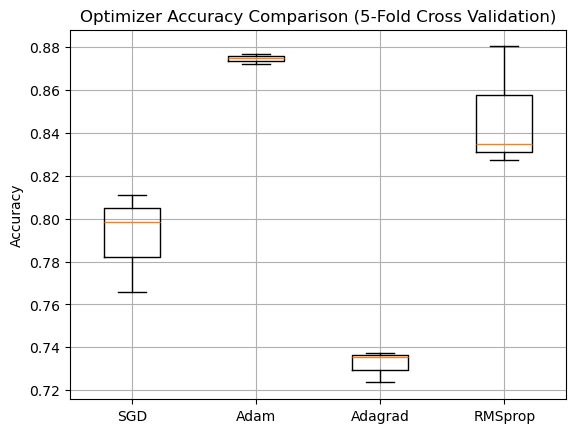

In [ ]:
# ---------------------------------------------------------------
# [전체 개요: 옵티마이저 성능 비교 실험 - 5겹 교차 검증 기반]
#
# 목적:
# 동일한 MLP 구조에서 여러 옵티마이저(SGD, Adam, Adagrad, RMSprop)의 분류 성능을 비교함
# 5-Fold 교차 검증을 통해 모델의 일반화 성능을 통계적으로 평가함
#
# 실험 배경:
# 옵티마이저는 학습 속도와 최종 정확도에 큰 영향을 미치며,
# 모델 구조나 데이터 특성에 따라 성능이 다르게 나타날 수 있음
# 따라서 동일한 조건에서 교차 검증을 통해 공정하게 성능을 비교함
# ---------------------------------------------------------------

# ---------------------------------------------------------------
# [처리 흐름 요약]
# 1단계: 필요한 라이브러리 및 데이터셋 로드
# 2단계: 입력/출력 데이터 전처리 수행
# 3단계: 모델 구조 및 학습 하이퍼파라미터 설정
# 4단계: 옵티마이저를 바꿔가며 교차 검증 수행
# 5단계: 결과 출력 및 시각화를 통한 비교 분석
# ---------------------------------------------------------------

import numpy as np  # 배열 연산 및 수치 계산을 위한 NumPy 모듈 임포트
import tensorflow as tf  # 신경망 모델 구현 및 학습을 위한 TensorFlow 프레임워크 임포트
tf.config.run_functions_eagerly(True)  
# TensorFlow를 즉시 실행 모드로 설정하여 디버깅과 반복학습에 유리한 실행 환경 구성

from tensorflow.keras.datasets import fashion_mnist  # Fashion MNIST 데이터셋 로드를 위한 모듈 임포트
from tensorflow.keras.models import Sequential  # 순차적 레이어 구성 방식을 위한 모델 클래스 임포트
from tensorflow.keras.layers import Dense  # 완전 연결층(Dense layer) 생성을 위한 레이어 클래스 임포트
from tensorflow.keras.optimizers import SGD, Adam, Adagrad, RMSprop  # 실험 대상 옵티마이저 클래스 임포트
from sklearn.model_selection import KFold  # K-Fold 교차 검증을 위한 분할 클래스 임포트
import matplotlib.pyplot as plt  # 실험 결과 시각화를 위한 matplotlib 임포트

# ---------------------------------------------------------------
# [1단계] Fashion MNIST 데이터셋 로드
# ---------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()  
# 훈련/테스트용 이미지 및 레이블 로드

# ---------------------------------------------------------------
# [2단계] 입력 및 출력 데이터 전처리
# ---------------------------------------------------------------

x_train = x_train.reshape(60000, 784).astype(np.float32) / 255.0  
# 28x28 이미지를 1차원 벡터로 변환한 후, 실수형 정규화 수행
x_test = x_test.reshape(10000, 784).astype(np.float32) / 255.0  
# 테스트셋도 동일한 방식으로 변환 및 정규화 수행

y_train = tf.keras.utils.to_categorical(y_train, 10)  
# 정수형 레이블을 one-hot 인코딩으로 변환하여 softmax와 호환 가능하게 처리
y_test = tf.keras.utils.to_categorical(y_test, 10)  
# 테스트셋 레이블에 대해서도 동일한 변환 수행

# ---------------------------------------------------------------
# [3단계] 신경망 구조 및 학습 파라미터 설정
# ---------------------------------------------------------------

n_input = 784     # 입력 뉴런 수 설정: 28x28 픽셀 평탄화 결과
n_hidden1 = 1024  # 첫 번째 은닉층 뉴런 수 설정
n_hidden2 = 512   # 두 번째 은닉층 뉴런 수 설정
n_hidden3 = 512   # 세 번째 은닉층 뉴런 수 설정
n_hidden4 = 512   # 네 번째 은닉층 뉴런 수 설정
n_output = 10     # 출력층 뉴런 수 설정: 10개 클래스 분류 문제

batch_siz = 256   # 미니배치 크기 설정
n_epoch = 5       # 에폭 수 설정
k = 5             # KFold 분할 수 설정: 5겹 교차 검증 수행

# ---------------------------------------------------------------
# [4단계] 모델 생성 함수 정의
# ---------------------------------------------------------------

def build_model():
    model = Sequential()  # 순차적 신경망 구조를 위한 모델 객체 생성
    model.add(Dense(units=n_hidden1, activation='relu', input_shape=(n_input,)))  
    # 입력층 + 은닉층 1 추가
    model.add(Dense(units=n_hidden2, activation='relu'))  # 은닉층 2 추가
    model.add(Dense(units=n_hidden3, activation='relu'))  # 은닉층 3 추가
    model.add(Dense(units=n_hidden4, activation='relu'))  # 은닉층 4 추가
    model.add(Dense(units=n_output, activation='softmax'))  # 출력층 추가: 다중 클래스 분류 확률 계산
    return model  # 구성된 모델 반환

# ---------------------------------------------------------------
# [5단계] 교차 검증 실행 함수 정의
# ---------------------------------------------------------------

def cross_validation(opt_class):  # 전달된 옵티마이저 클래스(opt_class)에 대해 교차 검증 수행
    accuracy = []  # fold별 정확도를 저장할 리스트 초기화

    for train_index, val_index in KFold(k).split(x_train):  
        # KFold 객체를 이용하여 학습/검증 데이터 인덱스 분할 수행
        xtrain, xval = x_train[train_index], x_train[val_index]  
        # 학습/검증 이미지 분리
        ytrain, yval = y_train[train_index], y_train[val_index]  
        # 학습/검증 레이블 분리

        dmlp = build_model()  # MLP 모델 구조 생성
        opt = opt_class()  # 전달받은 옵티마이저 클래스의 인스턴스 생성

        dmlp.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])  
        # 모델 컴파일 수행

        dmlp.fit(xtrain, ytrain, batch_size=batch_siz, epochs=n_epoch, verbose=0)  
        # 현재 fold에 대해 모델 학습 수행

        acc = dmlp.evaluate(xval, yval, verbose=0)[1]  # 검증셋 정확도 평가 수행 후 정확도 추출
        accuracy.append(acc)  # fold의 정확도를 리스트에 저장

    return accuracy  # k개의 fold에서 수집한 정확도 리스트 반환

# ---------------------------------------------------------------
# [6단계] 각 옵티마이저에 대한 교차 검증 수행
# ---------------------------------------------------------------

acc_sgd = cross_validation(SGD)  # SGD 옵티마이저에 대한 교차 검증 수행
acc_adam = cross_validation(Adam)  # Adam 옵티마이저에 대한 교차 검증 수행
acc_adagrad = cross_validation(Adagrad)  # Adagrad 옵티마이저에 대한 교차 검증 수행
acc_rmsprop = cross_validation(RMSprop)  # RMSprop 옵티마이저에 대한 교차 검증 수행

# ---------------------------------------------------------------
# [7단계] 평균 정확도 출력
# ---------------------------------------------------------------

print("SGD 옵티마이저의 평균 정확도:", np.mean(acc_sgd))  # SGD의 평균 정확도 출력
print("Adam 옵티마이저의 평균 정확도:", np.mean(acc_adam))  # Adam의 평균 정확도 출력
print("Adagrad 옵티마이저의 평균 정확도:", np.mean(acc_adagrad))  # Adagrad의 평균 정확도 출력
print("RMSprop 옵티마이저의 평균 정확도:", np.mean(acc_rmsprop))  # RMSprop의 평균 정확도 출력

# ---------------------------------------------------------------
# [8단계] 박스플롯 시각화
# ---------------------------------------------------------------

plt.boxplot([acc_sgd, acc_adam, acc_adagrad, acc_rmsprop],  # 옵티마이저별 정확도 리스트를 시각화
            labels=["SGD", "Adam", "Adagrad", "RMSprop"])  # 박스플롯 라벨 설정

plt.title("Optimizer Accuracy Comparison (5-Fold Cross Validation)")  # 그래프 제목 설정
plt.ylabel("Accuracy")  # y축 라벨 설정
plt.grid()  # 격자 표시 활성화
plt.show()  # 박스플롯 시각화 출력


In [ ]:
# ---------------------------------------------------------------
# [다양한 옵티마이저의 성능 비교: 5-Fold 교차 검증 + 커스텀 학습 루프]
# ---------------------------------------------------------------
# [전체 개요: 다양한 옵티마이저의 성능 비교 실험 - Fashion MNIST, 5-Fold 기반]
#
# 목적:
# 동일한 MLP 신경망 구조에서 서로 다른 옵티마이저(SGD, Adam, Adagrad, RMSprop)를 사용하여,
# 분류 정확도에 어떤 차이를 보이는지 실험적으로 비교하고, 5겹 교차 검증을 통해 평균 성능을 평가함
#
# 배경:
# 옵티마이저는 신경망 학습의 수렴 속도와 일반화 능력에 큰 영향을 주며,
# 데이터 특성 및 네트워크 깊이에 따라 최적의 선택이 달라질 수 있음
# 따라서 동일 조건에서 성능을 정량적으로 비교하는 과정이 필요함
# ---------------------------------------------------------------

# ---------------------------------------------------------------
# [처리 흐름 요약]
# 1단계: 데이터셋 로딩 및 전처리
# 2단계: 모델 구조 및 학습 하이퍼파라미터 정의
# 3단계: MLP 모델 생성 함수 정의
# 4단계: 교차 검증 함수 정의 및 실행
# 5단계: 옵티마이저별 평균 정확률 출력 및 박스플롯 시각화
# ---------------------------------------------------------------

import numpy as np  # 수치 계산 및 벡터/행렬 연산을 위한 NumPy 모듈 임포트
import tensorflow as tf  # 딥러닝 모델 구성 및 학습 수행을 위한 TensorFlow 프레임워크 임포트
from tensorflow.keras.datasets import fashion_mnist  # Fashion MNIST 이미지 데이터셋 로드 함수 임포트
from tensorflow.keras.models import Sequential  # 순차적 레이어 구성을 위한 모델 클래스 임포트
from tensorflow.keras.layers import Dense  # 완전 연결층(Dense layer) 생성을 위한 레이어 클래스 임포트
from sklearn.model_selection import KFold  # K겹 교차 검증을 위한 데이터 분할 클래스 임포트

# ---------------------------------------------------------------
# [1단계] Fashion MNIST 데이터셋 로딩 및 전처리
# ---------------------------------------------------------------

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()  
# 학습/테스트 이미지와 정답 라벨을 로드

x_train = x_train.reshape(60000, 784).astype(np.float32) / 255.0  
# 28x28 이미지를 1D 벡터로 변환하고 실수형으로 정규화 수행
x_test = x_test.reshape(10000, 784).astype(np.float32) / 255.0  
# 테스트셋도 동일한 전처리 수행

y_train = tf.keras.utils.to_categorical(y_train, 10)  
# 정수형 레이블을 one-hot 인코딩하여 softmax 출력과 매핑되도록 처리
y_test = tf.keras.utils.to_categorical(y_test, 10)  
# 테스트셋 라벨도 동일하게 인코딩 수행

# ---------------------------------------------------------------
# [2단계] 모델 구조 및 하이퍼파라미터 정의
# ---------------------------------------------------------------

n_input = 784      # 입력 뉴런 수 정의: 28x28 픽셀 평탄화
n_hidden1 = 1024   # 첫 번째 은닉층 뉴런 수 정의
n_hidden2 = 512    # 두 번째 은닉층 뉴런 수 정의
n_hidden3 = 512    # 세 번째 은닉층 뉴런 수 정의
n_hidden4 = 512    # 네 번째 은닉층 뉴런 수 정의
n_output = 10      # 출력 뉴런 수 정의: 총 10개 클래스 분류

batch_size = 256   # 학습 시 사용될 미니배치 크기 정의
n_epoch = 20       # 각 fold에 대해 반복할 학습 횟수 정의
k = 5              # KFold의 분할 개수 설정 (5겹 교차 검증)

# ---------------------------------------------------------------
# [3단계] MLP 모델 생성 함수 정의
# ---------------------------------------------------------------

def build_model():
    model = Sequential([  # 순차적 레이어 구성을 위한 모델 객체 생성
        Dense(n_hidden1, activation='relu', input_shape=(n_input,)),  
        # 입력층 + 은닉층1 정의 (ReLU 활성화)
        Dense(n_hidden2, activation='relu'),  # 은닉층2 정의
        Dense(n_hidden3, activation='relu'),  # 은닉층3 정의
        Dense(n_hidden4, activation='relu'),  # 은닉층4 정의
        Dense(n_output, activation='softmax')  # 출력층 정의: softmax를 통해 클래스별 확률 출력
    ])
    return model  # 구성된 MLP 모델 반환

# ---------------------------------------------------------------
# [4단계] 교차 검증 함수 정의
# ---------------------------------------------------------------

def cross_validation(opt):
    accuracy = []  # 각 fold에서 얻은 정확률을 저장할 리스트 초기화

    for train_index, val_index in KFold(k).split(x_train):  
        # 학습 데이터셋을 KFold 방식으로 분할하여 인덱스 생성
        xtrain, xval = x_train[train_index], x_train[val_index]  # 훈련 및 검증 입력셋 분할
        ytrain, yval = y_train[train_index], y_train[val_index]  # 훈련 및 검증 레이블 분할

        dmlp = build_model()  # 새로운 MLP 모델 인스턴스 생성

        dmlp.compile(optimizer=opt,  # 지정된 옵티마이저로 학습 설정
                     loss='categorical_crossentropy',  # 다중 클래스 분류 손실 함수 설정
                     metrics=['accuracy'])  # 정확도 지표 설정

        dmlp.fit(xtrain, ytrain, batch_size=batch_size, epochs=n_epoch, verbose=0)  
        # 현재 fold에 대해 학습 수행
        accuracy.append(dmlp.evaluate(xval, yval, verbose=0)[1])  
        # 검증 정확도를 평가하여 리스트에 추가

    return accuracy  # 모든 fold의 정확도를 반환

# ---------------------------------------------------------------
# [5단계] 다양한 옵티마이저에 대해 교차 검증 실행
# ---------------------------------------------------------------

acc_sgd = cross_validation(tf.keras.optimizers.legacy.SGD())  
# SGD 옵티마이저 사용 시 정확도 평가
acc_adam = cross_validation(tf.keras.optimizers.legacy.Adam())  
# Adam 옵티마이저 사용 시 정확도 평가
acc_adagrad = cross_validation(tf.keras.optimizers.legacy.Adagrad())  
# Adagrad 옵티마이저 사용 시 정확도 평가
acc_rmsprop = cross_validation(tf.keras.optimizers.legacy.RMSprop())  
# RMSprop 옵티마이저 사용 시 정확도 평가

# ---------------------------------------------------------------
# [6단계] 평균 정확률 출력
# ---------------------------------------------------------------

print("SGD:", np.array(acc_sgd).mean())  # SGD의 평균 정확률 출력
print("Adam:", np.array(acc_adam).mean())  # Adam의 평균 정확률 출력
print("Adagrad:", np.array(acc_adagrad).mean())  # Adagrad의 평균 정확률 출력
print("RMSprop:", np.array(acc_rmsprop).mean())  # RMSprop의 평균 정확률 출력

# ---------------------------------------------------------------
# [7단계] 옵티마이저별 정확률 분포 박스플롯 시각화
# ---------------------------------------------------------------

import matplotlib.pyplot as plt  # 결과 시각화를 위한 matplotlib.pyplot 임포트

plt.boxplot([acc_sgd, acc_adam, acc_adagrad, acc_rmsprop],  # 각 옵티마이저의 교차 검증 정확률 리스트 제공
            labels=["SGD", "Adam", "Adagrad", "RMSprop"])  # 박스플롯 라벨 지정

plt.grid()  # 격자 표시를 통해 비교 가독성 향상
plt.show()  # 박스플롯 시각화 출력



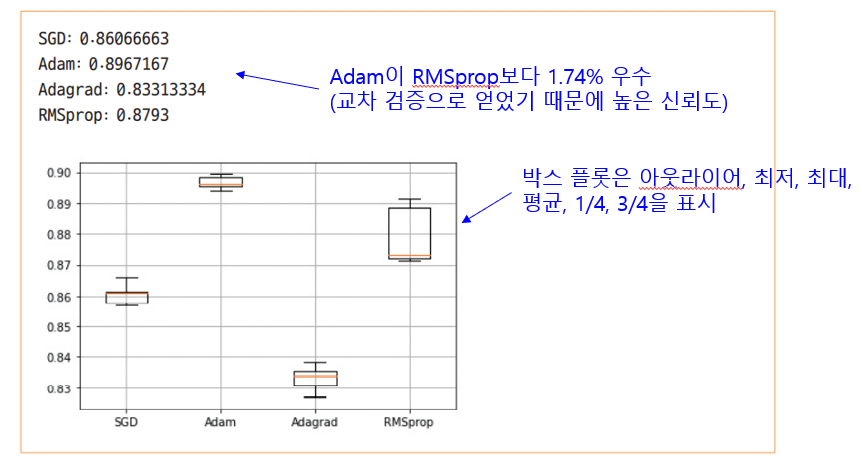